In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import linregress
import itertools as it
from matplotlib import rcParams
from utils.analysis import uq_get_obs, uq_get_sim

rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

prefix_default = '20231116'
#prefix_uptake = '20240401'
prefix_list = [prefix_default] #, prefix_uptake] # , '20240316_2']

pft_names = ['Spruce', 'Tamarack', 'Shrub']

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

chambers_ordered = {
    'amb': ['7', '6', '20', '13', '8', '17'],
    'elev': ['19', '11', '4', '16', '10']
}

def fit_line(x, y):
    filt = ~np.isnan(x) & ~np.isnan(y)
    x = x[filt]
    y = y[filt]

    if sum(filt) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    res = linregress(x, y)
    xnew = np.linspace(x.min(), x.max(), 3)
    ynew = res.slope * xnew + res.intercept
    r2 = res.rvalue**2  # coefficient of determination
    return xnew, ynew, res.slope, res.intercept, r2

In [2]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
prefix_list_uq = ['UQ_20231116', 'UQ_20240101'] # , 'UQ_20240312_test20241017']
N_list = [4000, 4000]
BLOCK_LIST = [200, 200]
VAR_LIST = ['AGBiomass_Spruce', 'AGBiomass_Tamarack', 'AGBiomass_Shrub',
            'AGNPPtoBiomass_Spruce', 'AGNPPtoBiomass_Tamarack', 'AGNPPtoBiomass_Shrub',
            'AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
            'BGNPP_TreeShrub', 'BGtoAG_TreeShrub', 'NPP', 'HR', 'NEE']

collection_obs = uq_get_obs(VAR_LIST)

collection_sim = {}
for N, BLOCK, prefix in zip(N_list, BLOCK_LIST, prefix_list_uq):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :, :] = np.load(os.path.join(
            os.environ['PROJDIR'], 'ELM_Phenology', 'output', "extract", prefix,
            f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)[:, 1:, :, :] # TEMPORARY
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)
    # revert the signs of NEE & HR to be compatible with Paul's data
    # collect[:, -3:-1, :, :] = - collect[:, -3:-1, :, :]
    # TEMPORARY
    collect[:, -2:, :, :] = - collect[:, -2:, :, :]

    collection_sim[prefix] = collect

collection_sim_target = {}
for prefix in prefix_list:
    collection_sim_target[prefix] = uq_get_sim(prefix, VAR_LIST)

/autofs/nccsopen-svm1_home/ywo/Git/phenology_elm/utils/analysis.py:1123: PerformanceWarning: indexing past lexsort depth may impact performance.
  sim_tair = sim_data.loc['average', 'Tair']


/tmp/ipykernel_661001/1691868086.py:100: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "-or" (-> color='r'). The keyword argument will take precedence.
  h4[p], = ax.plot(sims_target_slope[prefix][0, :], '-or', color = clist[2 + p])


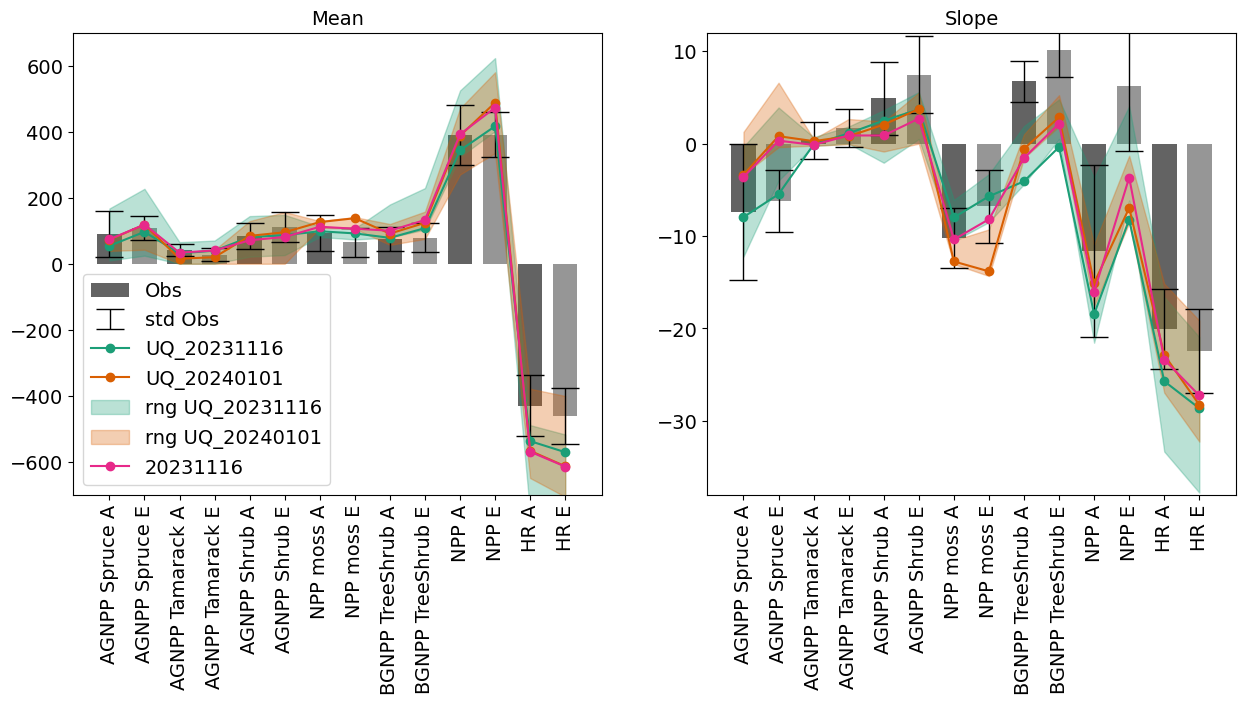

In [14]:
# Make a nicer graph that overlays the top 10 best runs of each prefix_list
VAR_SUBSET =  ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub', 'NPP_moss',
               'BGNPP_TreeShrub','NPP','HR']
xticklabels = [var.replace('_',' ')+f' {co2}' for var in VAR_SUBSET for co2 in ['A', 'E']]
ind_list = [] # the index to VAR_SUBSET that we are interested in
for i,var in enumerate(VAR_LIST):
    if var in VAR_SUBSET:
        ind_list.append(i)
ind_list = np.array(ind_list)

#
n_best_ind = 40
obs_mean = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 0].reshape(1,-1)
obs_mean_std = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 1].reshape(1,-1)
obs_slope = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 2].reshape(1,-1)
obs_slope_std = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 3].reshape(1,-1)
sims_target_mean = {}
sims_target_slope = {}
for prefix in collection_sim_target:
    sims_target_mean[prefix] = collection_sim_target[prefix].values.reshape(-1, 2, 
        4)[ind_list, :, 0].reshape(1, -1)
    sims_target_slope[prefix] = collection_sim_target[prefix].values.reshape(-1, 2, 
        4)[ind_list, :, 2].reshape(1, -1)

#
fig, axes = plt.subplots(1, 2, figsize = (15, 6), sharex = True)
ax = axes[0]
h1 = ax.bar(np.arange(obs_mean.shape[1]), obs_mean[0, :], width = 0.7,
            color = ['#636363', '#969696'] * len(VAR_SUBSET))
he = ax.errorbar(np.arange(obs_mean.shape[1]), obs_mean[0, :], yerr = obs_mean_std[0, :], lw = 0, 
            ecolor = 'k', elinewidth = 1, capsize = 10, barsabove = True)
ax.set_title('Mean')
ax = axes[1]
h1 = ax.bar(np.arange(obs_slope.shape[1]), obs_slope[0, :], width = 0.7,
            color = ['#636363', '#969696'] * len(VAR_SUBSET))
ax.errorbar(np.arange(obs_slope.shape[1]), obs_slope[0, :], yerr = obs_slope_std[0, :], lw = 0, 
            ecolor = 'k', elinewidth = 1, capsize = 10, barsabove = True)
ax.set_title('Slope')

clist = ['#1b9e77', '#d95f02', '#e7298a', '#800074'] # '#1a80bb'
h2 = [None] * len(prefix_list_uq)
h3 = [None] * len(prefix_list_uq)
for p, prefix in enumerate(prefix_list_uq):

    # the 2 is ACO2 and ECO2
    sim_mean = collection_sim[prefix][:, ind_list, :][:,:,:,0].reshape(-1, 2*len(ind_list))
    sim_slope = collection_sim[prefix][:, ind_list, :][:,:,:,2].reshape(-1, 2*len(ind_list))

    # find the best runs
    rmse_mean = np.sqrt(np.mean(np.power((sim_mean - obs_mean) / \
                                        (np.abs(obs_mean)) * 2, 2),
                                axis = 1))
    rmse_slope = np.sqrt(np.mean(np.power((sim_slope - obs_slope) / \
                                        (np.abs(obs_slope)) * 2, 2),
                                axis = 1))
    rmse_tot = np.sqrt((rmse_mean**2 + rmse_slope**2)/2)
    best_inds = np.argpartition(rmse_tot, n_best_ind)[:n_best_ind]

    sim_mean_bi = sim_mean[best_inds, :]
    sim_slope_bi = sim_slope[best_inds, :]

    ax = axes[0]
    if prefix == 'UQ_20231113':
        h2[p], = ax.plot(sim_mean[681, :], '-o', color = clist[p])
    elif prefix == 'UQ_20231116':
        h2[p], = ax.plot(sim_mean[3567, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240101':
        h2[p], = ax.plot(sim_mean[225, :], '-o', color = clist[p])
    else:
        h2[p], = ax.plot(sim_mean_bi.mean(axis = 0), '-o', color = clist[p])
    h3[p] = ax.fill_between(np.arange(sim_mean_bi.shape[1]), 
                            np.min(sim_mean_bi, axis = 0),
                            np.max(sim_mean_bi, axis = 0), color = clist[p], alpha = 0.3)

    ax.set_ylim([-700, 700])

    ax = axes[1]
    if prefix == 'UQ_20231113':
        h2[p], = ax.plot(sim_slope[681, :], '-o', color = clist[p])
    elif prefix == 'UQ_20231116':
        h2[p], = ax.plot(sim_slope[3567, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240101':
        h2[p], = ax.plot(sim_slope[225, :], '-o', color = clist[p])
    else:
        h2[p], = ax.plot(sim_slope_bi.mean(axis = 0), '-o', color = clist[p])
    h3[p] = ax.fill_between(np.arange(sim_slope_bi.shape[1]), 
                            np.min(sim_slope_bi, axis = 0),
                            np.max(sim_slope_bi, axis = 0), color = clist[p], alpha = 0.3)
    ax.set_xticks(np.arange(sim_slope_bi.shape[1]))
    ax.set_ylim([-38, 12])

h4 = [None] * 2
for p, prefix in enumerate(prefix_list):
    ax = axes[0]
    h4[p], = ax.plot(sims_target_mean[prefix][0, :], '-o', color = clist[2 + p])
    ax.set_xticks(np.arange(sims_target_mean[prefix].shape[1]))
    ax.set_xticklabels(xticklabels, rotation = 90)

    ax = axes[1]
    h4[p], = ax.plot(sims_target_slope[prefix][0, :], '-or', color = clist[2 + p])
    ax.set_xticks(np.arange(sims_target_slope[prefix].shape[1]))
    ax.set_xticklabels(xticklabels, rotation = 90)
    #ax.grid(True)

ax = axes[0]
ax.legend([h1, he] + h2 + h3 + h4, ['Obs', 'std Obs'] + \
          prefix_list_uq + [f'rng {x}' for x in prefix_list_uq] + \
          prefix_list,
          loc = 'lower left')